# Árboles de decisión

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import export_graphviz
from sklearn.model_selection import cross_val_score
from sklearn.metrics import f1_score, mean_absolute_error, r2_score, root_mean_squared_error, mean_absolute_percentage_error, fbeta_score, make_scorer
import joblib
sns.set()

In [39]:
data = joblib.load('../data/processed_data.pkl')
columns = data['feature_names']
X_train = pd.DataFrame(data['X_train'], columns=columns)
X_test = pd.DataFrame(data['X_test'], columns=columns)
y_train = data['y_train']
y_test = data['y_test']


FileNotFoundError: [Errno 2] No such file or directory: '../datasets/X_train.csv'

In [40]:
X_train.dropna(subset=['gender'], inplace=True)
y_train = y_train.loc[X_train.index]

In [42]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((3576, 14), (1533, 14), (3576,), (1533,))

In [43]:
y_train.value_counts()

stroke
0         3402
1          174
Name: count, dtype: int64

Las clases están muy desbalanceadas, entonces vamos a usar DecisionTreeClassifier con class_weight = 'balanced', de este modo utiliza los valores de y para ajustar automáticamente los pesos inversamente proporcionales a las frecuencias de clase en los datos de entrada como n_samples / (n_classes * np.bincount(y))

Ahora vamos a aplicar el modelo, primero llamamos al modelo de [árbol de clasificación](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html)

In [65]:
from sklearn.tree import DecisionTreeClassifier

# Creamos el arbol
classification = DecisionTreeClassifier(criterion='entropy', splitter='best', class_weight='balanced',
                                        max_depth=None, min_samples_split=2, min_samples_leaf=1, 
                                        random_state=42)
# Y entrenamos
classification.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', criterion='entropy',
                       random_state=42)

In [66]:
classification.get_params()

{'ccp_alpha': 0.0,
 'class_weight': 'balanced',
 'criterion': 'entropy',
 'max_depth': None,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'random_state': 42,
 'splitter': 'best'}

Podemos ver a nuestro arbol para entender que hizo usando export_graphviz

In [50]:
export_graphviz(classification, out_file = "arbol_clasificacion.dot",
                feature_names=X_train.columns,
                class_names=["No tiene enfermedad cardiaca", "Tiene enfermedad cardiaca"],
                rounded=True,
                filled=True)

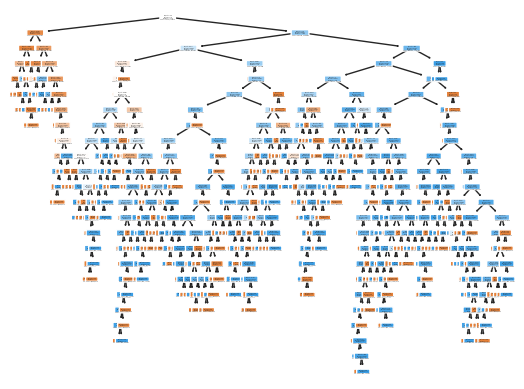

In [71]:
from sklearn.tree import plot_tree
plot_tree(classification, filled=True, rounded=True);

Midamos como este modelo performa usando el F1-score:

In [67]:
y_pred_train = classification.predict(X_train)
y_pred = classification.predict(X_test)

f1_train = f1_score(y_train, y_pred_train)
f1 = f1_score(y_test, y_pred)
f2 = fbeta_score(y_test, y_pred, beta=4)

print(f"F1-score de entreamiento fue: {f1_train}")
print(f"F1-score de testeo fue: {f1}")
print(f"F2-score de testeo fue: {f2}")

F1-score de entreamiento fue: 1.0
F1-score de testeo fue: 0.1702127659574468
F2-score de testeo fue: 0.16113744075829384


F1-score fue muy bajo para el testeo, lo cual muestra que el modelo no es muy robusto

In [72]:
classification.get_params()

{'ccp_alpha': 0.0,
 'class_weight': 'balanced',
 'criterion': 'entropy',
 'max_depth': None,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'random_state': 42,
 'splitter': 'best'}

Podemos hacer una búsqueda de hiper-parámetros pero buscando con otros parámetros del modelo, usando optuna:

In [100]:
import optuna
beta = 2
ftwo_scorer = make_scorer(fbeta_score, beta=beta)

def objective(trial):
    max_depth = trial.suggest_int("max_depth", 1, 30)
    criterion = trial.suggest_categorical("criterion", ["gini", "entropy"])
    class_weight = trial.suggest_categorical("class_weight", ["balanced", None])
    min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)

    classifier = DecisionTreeClassifier(criterion=criterion, splitter='best', class_weight=class_weight,
                                        max_depth=max_depth, min_samples_split=min_samples_split, 
                                        min_samples_leaf=min_samples_leaf, random_state=42)
    
    # Realizamos la validación cruzada
    score = cross_val_score(classifier, X_train, y_train, cv=10, scoring="recall", n_jobs=-1)
    
    return score.mean()

In [101]:
def champion_callback(study, frozen_trial):
    """
    Mostramos menos información, sino es demasiado verboso
    """
    winner = study.user_attrs.get("winner", None)
    if study.best_value and winner != study.best_value:
        study.set_user_attr("winner", study.best_value)
        if winner:
            improvement_percent = (abs(winner - study.best_value) / study.best_value) * 100
            print(
                f"Trial {frozen_trial.number} achieved value: {frozen_trial.value} with "
                f"{improvement_percent: .4f}% improvement"
            )
        else:
            print(f"Initial trial {frozen_trial.number} achieved value: {frozen_trial.value}")

In [102]:
# Creamos un estudio de Optuna
# Optuna es un poco verboso, dejamos que solo nos muestre logs de errores
optuna.logging.set_verbosity(optuna.logging.ERROR)

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=1000, callbacks=[champion_callback])

Initial trial 0 achieved value: 0.7029411764705883
Trial 10 achieved value: 0.9490196078431372 with  25.9298% improvement


In [103]:
# Obtenemos los mejores hiperparámetros encontrados
best_params = study.best_params
best_params

{'max_depth': 1,
 'criterion': 'entropy',
 'class_weight': 'balanced',
 'min_samples_split': 3,
 'min_samples_leaf': 20}

In [104]:
# Creamos el arbol
classification = DecisionTreeClassifier(**best_params, random_state=42)
# Y entrenamos
classification.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', criterion='entropy',
                       max_depth=1, min_samples_leaf=18, min_samples_split=10,
                       random_state=42)

In [105]:
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score

y_pred = classification.predict(X_test)

metrics_tree = {
    "name": "Arbol de Clasificacion",
    "Recall": recall_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Accuracy": accuracy_score(y_test, y_pred),    
    "F1": f1_score(y_test, y_pred),
    "F2": fbeta_score(y_test, y_pred, beta=beta)
}

metrics_tree

{'name': 'Arbol de Clasificacion',
 'Recall': 0.8666666666666667,
 'Precision': 0.09433962264150944,
 'Accuracy': 0.5864318330071755,
 'F1': 0.17015706806282724,
 'F2': 0.32861476238624876}

In [41]:
export_graphviz(classification, out_file="arbol_clasificacion_level7.dot",
                feature_names=df_heart.columns[:-1],
                class_names=["No tiene enfermedad cardiaca", "Tiene enfermedad cardiaca"],
                rounded=True,
                filled=True)

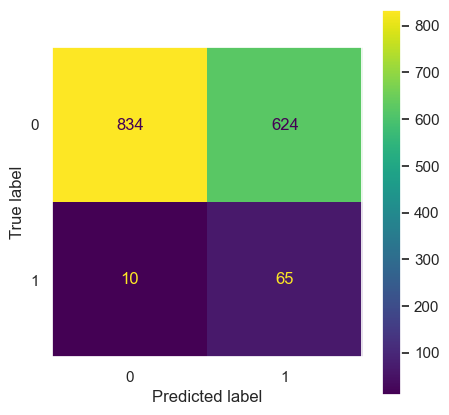

In [106]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred, labels=classification.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classification.classes_)

fig, ax = plt.subplots(figsize=(5,5))
ax.grid(False)
disp.plot(ax=ax);

Veamos la curva ROC:

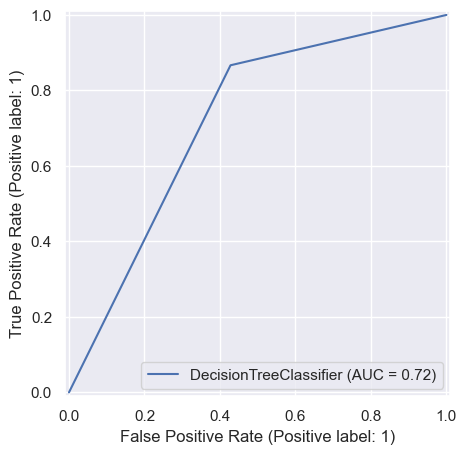

In [107]:
from sklearn.metrics import RocCurveDisplay
    
fig, ax = plt.subplots(figsize=(5,5))
svc_disp = RocCurveDisplay.from_estimator(classification, X_test, y_test, ax=ax)

plt.show();

### Bagging

In [81]:
X_train.columns

{'name': 'Bagging',
 'Recall': 0.8666666666666667,
 'Precision': 0.09433962264150944,
 'Accuracy': 0.5864318330071755,
 'F1': 0.44737219172037973,
 'F2': 0.32861476238624876}

In [86]:
from sklearn.ensemble import RandomForestClassifier

# Creamos un bosque aleatorio por defecto (100 árboles)
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(X_train, y_train)

# Calculamos las métricas
y_pred_rf = rf_classifier.predict(X_test)

metrics_rf = {
    "name": "Random Forest",
    "Recall": recall_score(y_test, y_pred_rf),
    "Precision": precision_score(y_test, y_pred_rf),
    "Accuracy": accuracy_score(y_test, y_pred_rf),    
    "F1": f1_score(y_test, y_pred_rf, average='macro'),
    "F2": fbeta_score(y_test, y_pred_rf, beta=beta)
}

metrics_rf

{'name': 'Random Forest',
 'Recall': 0.013333333333333334,
 'Precision': 0.25,
 'Accuracy': 0.9497716894977168,
 'F1': 0.49976904137337747,
 'F2': 0.01644736842105263}

### Boosting

In [24]:
from sklearn.ensemble import AdaBoostClassifier

# Configuramos también la cantidad y la constante de aprendizaje
adaboost_classifier = AdaBoostClassifier(estimator=classification, n_estimators=500, random_state=42, learning_rate=0.01)
adaboost_classifier.fit(X_train, y_train)

# Calculamos las métricas
y_pred_ada = adaboost_classifier.predict(X_test)

metrics_ada = {
    "name": "AdaBoost",
    "Recall": recall_score(y_test, y_pred_ada),
    "Precision": precision_score(y_test, y_pred_ada),
    "Accuracy": accuracy_score(y_test, y_pred_ada),    
    "F1": f1_score(y_test, y_pred_ada),
    "F2": fbeta_score(y_test, y_pred_ada, beta=beta)
}

metrics_ada

{'name': 'AdaBoost',
 'Recall': 0.8666666666666667,
 'Precision': 0.09433962264150944,
 'Accuracy': 0.5864318330071755,
 'F1': 0.17015706806282724,
 'F2': 0.32861476238624876}

### XGBoost

In [25]:
import xgboost as xgb

# Inicializamos XGBoost con sus hiperparámetros por defecto
xgb_classifier = xgb.XGBClassifier(random_state=42, n_jobs=-1, max_depth=100)
xgb_classifier.fit(X_train, y_train)

# Calculamos las métricas
y_pred_xgb = xgb_classifier.predict(X_test)

metrics_xgb = {
    "name": "XGBoost",
    "Recall": recall_score(y_test, y_pred_xgb),
    "Precision": precision_score(y_test, y_pred_xgb),
    "Accuracy": accuracy_score(y_test, y_pred_xgb),    
    "F1": f1_score(y_test, y_pred_xgb),
    "F2": fbeta_score(y_test, y_pred_xgb, beta=beta)
}
metrics_xgb

{'name': 'XGBoost',
 'Recall': 0.04,
 'Precision': 0.13636363636363635,
 'Accuracy': 0.9406392694063926,
 'F1': 0.061855670103092786,
 'F2': 0.046583850931677016}

In [26]:
models_metrics = [metrics_ada, metrics_rf, metrics_bag, metrics_xgb, metrics_tree] 

# Crear el DataFrame
df_results = pd.DataFrame(models_metrics)

# (Opcional) Poner el nombre como índice para que sea la primera columna
df_results.set_index('name', inplace=True)

print(df_results)

                          Recall  Precision  Accuracy        F1        F2
name                                                                     
AdaBoost                0.866667   0.094340  0.586432  0.170157  0.328615
Random Forest           0.013333   0.250000  0.949772  0.499769  0.016447
Bagging                 0.866667   0.094340  0.586432  0.447372  0.328615
XGBoost                 0.040000   0.136364  0.940639  0.061856  0.046584
Arbol de Clasificacion  0.866667   0.094340  0.586432  0.170157  0.328615


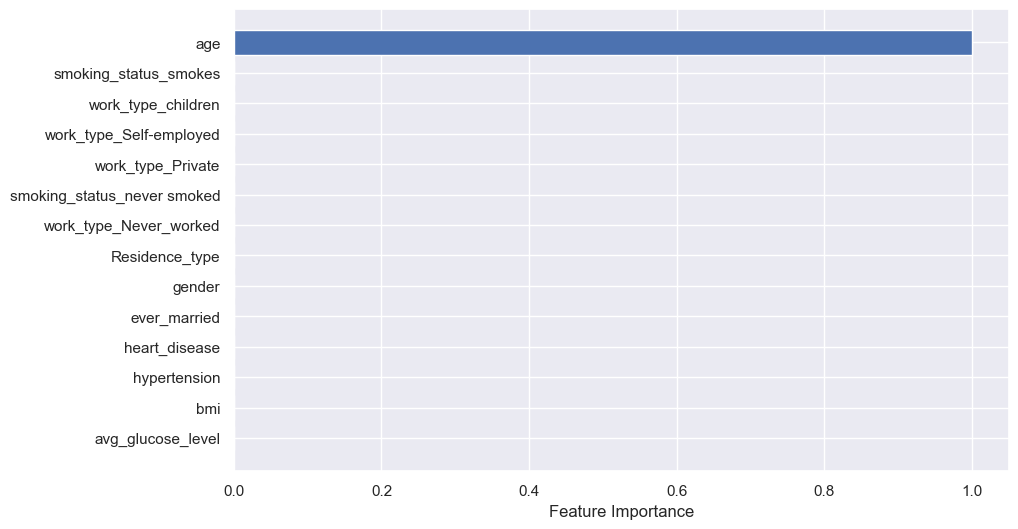

In [27]:
# Obtenemos la importancia de características
feature_importances = np.mean([tree.feature_importances_ for tree in adaboost_classifier.estimators_], axis=0)
feature_names = X_test.columns

# Ordenamos los índices
sorted_idx = feature_importances.argsort()

plt.figure(figsize=(10, 6))
plt.barh(range(len(sorted_idx)), feature_importances[sorted_idx], align='center')
plt.yticks(range(len(sorted_idx)), [feature_names[i] for i in sorted_idx])
plt.xlabel('Feature Importance')
plt.show()

In [28]:
X_train

,age,avg_glucose_level,bmi,hypertension,heart_disease,gender,ever_married,Residence_type,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,smoking_status_never smoked,smoking_status_smokes
0,0.388807,0.042123,-0.881352,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.833425,-0.392226,0.958802,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
2,1.678198,-0.232683,0.070896,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
3,0.522192,-0.720435,-0.109259,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
4,-0.278120,-0.050888,0.933066,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3571,0.077574,-0.291204,0.804383,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
3572,-1.211817,0.167399,-1.203057,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
3573,0.788963,-0.607397,0.945934,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3574,1.633737,-0.653681,0.675701,0.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0


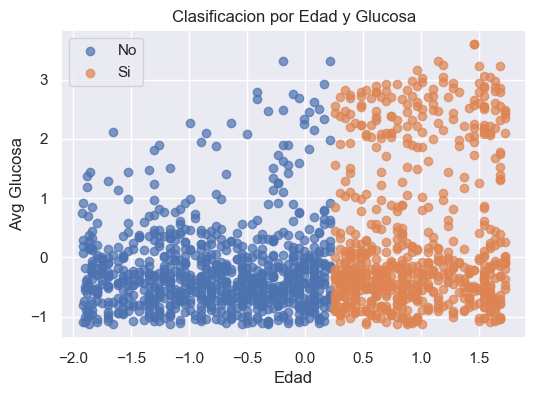

In [87]:
plt.figure(figsize=(6, 4))
for i, target_name in enumerate(["No", "Si"]):
    plt.scatter(X_test[y_pred == i]['age'], X_test[y_pred == i]['avg_glucose_level'], label=target_name, alpha=0.7)
plt.xlabel("Edad")
plt.ylabel("Avg Glucosa")
plt.legend()
plt.title("Clasificacion por Edad y Glucosa")
plt.show()

### Exportar Modelo

In [30]:
import os
os.makedirs("../models", exist_ok=True)
joblib.dump(adaboost_classifier, '../models/adam_model.pkl')
joblib.dump(classification, '../models/decision_tree_classifier.pkl')

['../models/decision_tree_classifier.pkl']